# LAB HƯỚNG DẪN: XỬ LÝ ẢNH VÀ PHÂN ĐOẠN ĐỐI TƯỢNG

## PHẦN 1: CHUẨN BỊ VÀ IMPORT THƯ VIỆN

### Bước 1: Mở Google Colab và tạo notebook mới

### Bước 2: Import các thư viện cần thiết

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from PIL import Image
from google.colab import files
from google.colab import drive
import io

## PHẦN 2: TẢI ẢNH VÀO COLAB

### Bước 3: Tạo các hàm tải ảnh

In [2]:
# CÁCH 1: Upload ảnh từ máy tính
def load_image_from_upload():
    print("Chọn file ảnh từ máy tính:")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    image = Image.open(io.BytesIO(uploaded[filename]))
    return image

# CÁCH 2: Đọc ảnh từ Google Drive
def load_image_from_drive(file_path):
    drive.mount('/content/drive')
    image = Image.open(file_path)
    return image

# CÁCH 3: Tải ảnh từ URL (bonus)
def load_image_from_url(url):
    import requests
    response = requests.get(url)
    image = Image.open(io.BytesIO(response.content))
    return image

### Bước 4: Chọn phương pháp tải ảnh

In [3]:
# Cấu hình
method = 1  # 1: upload, 2: Google Drive, 3: URL
threshold = 200  # Ngưỡng cho ảnh nhị phân
structure_size = 5  # Kích thước structure element cho opening

# Tải ảnh theo phương pháp được chọn
if method == 1:
    image = load_image_from_upload()
elif method == 2:
    drive_path = '/content/drive/MyDrive/animal.jpg'
    image = load_image_from_drive(drive_path)
elif method == 3:
    url = 'https://example.com/your-image.jpg'  # Thay bằng URL thực
    image = load_image_from_url(url)

Chọn file ảnh từ máy tính:


Saving animal.jpg to animal.jpg


## PHẦN 3: XỬ LÝ ẢNH CƠ BẢN

### Bước 5: Chuyển đổi ảnh sang ảnh xám

In [4]:
# Chuyển sang ảnh xám
gray_image = image.convert('L')
image_array = np.array(gray_image)

# Hiển thị thông tin ảnh
print(f"Kích thước ảnh gốc: {image.size}")
print(f"Kích thước mảng ảnh xám: {image_array.shape}")
print(f"Giá trị pixel min-max: {image_array.min()} - {image_array.max()}")

Kích thước ảnh gốc: (509, 339)
Kích thước mảng ảnh xám: (339, 509)
Giá trị pixel min-max: 0 - 255


### Bước 6: Tạo ảnh nhị phân

In [5]:
# Chuyển sang ảnh nhị phân
binary_image = 1 * (image_array < threshold)

# Thống kê ảnh nhị phân
white_pixels = np.sum(binary_image == 1)
black_pixels = np.sum(binary_image == 0)
total_pixels = binary_image.size

print(f"Ngưỡng nhị phân: {threshold}")
print(f"Pixel trắng (đối tượng): {white_pixels} ({white_pixels/total_pixels*100:.1f}%)")
print(f"Pixel đen (nền): {black_pixels} ({black_pixels/total_pixels*100:.1f}%)")

Ngưỡng nhị phân: 200
Pixel trắng (đối tượng): 41266 (23.9%)
Pixel đen (nền): 131285 (76.1%)


## PHẦN 4: PHÉP TOÁN HÌNH THÁI HỌC (MORPHOLOGICAL OPERATIONS)

### Bước 7: Hiểu về phép Opening

### Bước 8: Áp dụng phép Opening

In [6]:
# Tạo structure element (kernel)
structure_element = np.ones((structure_size, structure_size))
# Áp dụng phép Opening (Erosion followed by Dilation)
opened_image = ndimage.binary_opening(binary_image,
                                     structure=structure_element)
# So sánh trước và sau Opening
objects_before = ndimage.label(binary_image)[1]
objects_after = ndimage.label(opened_image)[1]

print(f"Kích thước structure element: {structure_size}x{structure_size}")
print(f"Số đối tượng trước Opening: {objects_before}")
print(f"Số đối tượng sau Opening: {objects_after}")
print(f"Số đối tượng bị loại bỏ: {objects_before - objects_after}")

Kích thước structure element: 5x5
Số đối tượng trước Opening: 63
Số đối tượng sau Opening: 25
Số đối tượng bị loại bỏ: 38


## PHẦN 5: PHÂN ĐOẠN VÀ ĐÁNH NHÃN ĐỐI TƯỢNG

### Bước 9: Đánh nhãn các đối tượng

In [7]:
# Đánh nhãn các đối tượng connected
labeled_image, num_features = ndimage.label(opened_image)

print(f"Số đối tượng được phát hiện: {num_features}")

# Thông tin chi tiết về các đối tượng
for i in range(1, num_features + 1):
    object_pixels = np.sum(labeled_image == i)
    print(f"Đối tượng {i}: {object_pixels} pixels")

Số đối tượng được phát hiện: 25
Đối tượng 1: 6320 pixels
Đối tượng 2: 387 pixels
Đối tượng 3: 30 pixels
Đối tượng 4: 311 pixels
Đối tượng 5: 142 pixels
Đối tượng 6: 230 pixels
Đối tượng 7: 201 pixels
Đối tượng 8: 956 pixels
Đối tượng 9: 1096 pixels
Đối tượng 10: 933 pixels
Đối tượng 11: 1095 pixels
Đối tượng 12: 1082 pixels
Đối tượng 13: 720 pixels
Đối tượng 14: 1964 pixels
Đối tượng 15: 1961 pixels
Đối tượng 16: 1066 pixels
Đối tượng 17: 1058 pixels
Đối tượng 18: 1085 pixels
Đối tượng 19: 1092 pixels
Đối tượng 20: 1976 pixels
Đối tượng 21: 941 pixels
Đối tượng 22: 1065 pixels
Đối tượng 23: 939 pixels
Đối tượng 24: 1051 pixels
Đối tượng 25: 1048 pixels


### Bước 10: Phân tích các đối tượng

In [8]:
# Tìm đối tượng lớn nhất và nhỏ nhất
object_sizes = []
for i in range(1, num_features + 1):
    size = np.sum(labeled_image == i)
    object_sizes.append(size)

if object_sizes:
    largest_size = max(object_sizes)
    smallest_size = min(object_sizes)
    avg_size = np.mean(object_sizes)

    print(f"Kích thước đối tượng lớn nhất: {largest_size} pixels")
    print(f"Kích thước đối tượng nhỏ nhất: {smallest_size} pixels")
    print(f"Kích thước trung bình: {avg_size:.1f} pixels")

Kích thước đối tượng lớn nhất: 6320 pixels
Kích thước đối tượng nhỏ nhất: 30 pixels
Kích thước trung bình: 1150.0 pixels


## PHẦN 6: HIỂN THỊ VÀ PHÂN TÍCH KẾT QUẢ

### Bước 11: Tạo visualization hoàn chỉnh

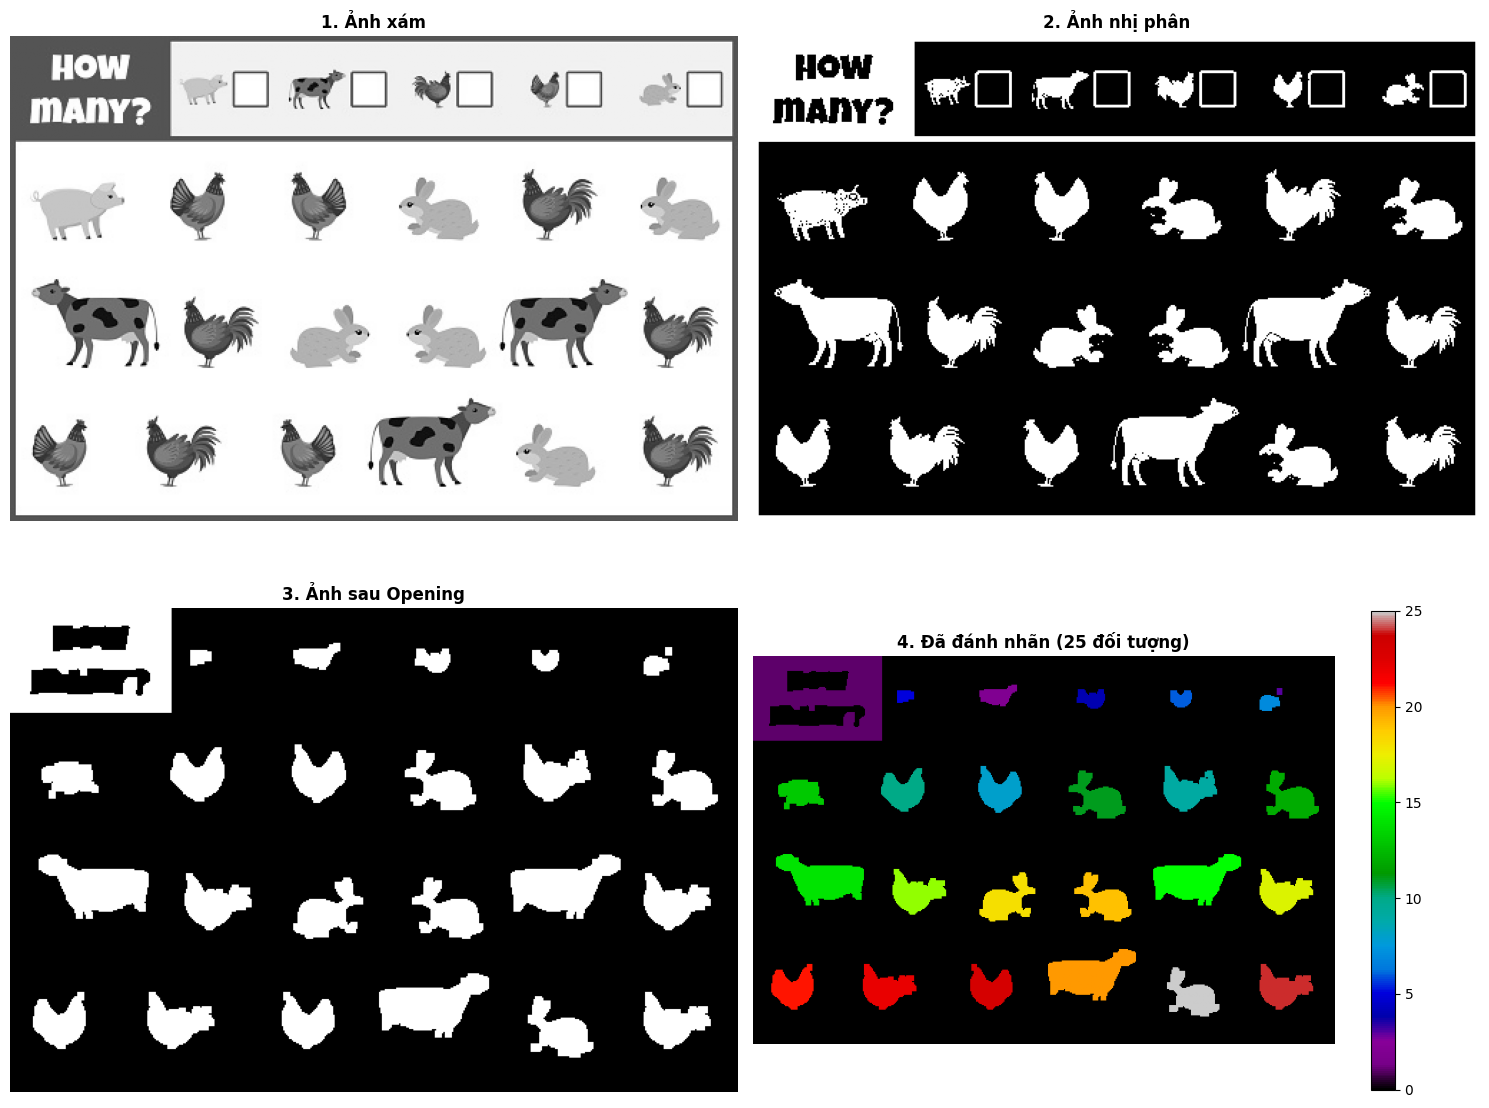

In [9]:
# Hiển thị kết quả trong layout 2x2
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Ảnh xám
axs[0,0].imshow(gray_image, cmap='gray')
axs[0,0].set_title("1. Ảnh xám", fontsize=12, fontweight='bold')
axs[0,0].axis('off')

# Ảnh nhị phân
axs[0,1].imshow(binary_image, cmap='gray')
axs[0,1].set_title("2. Ảnh nhị phân", fontsize=12, fontweight='bold')
axs[0,1].axis('off')

# Ảnh sau Opening
axs[1,0].imshow(opened_image, cmap='gray')
axs[1,0].set_title("3. Ảnh sau Opening", fontsize=12, fontweight='bold')
axs[1,0].axis('off')

# Ảnh đã đánh nhãn
im = axs[1,1].imshow(labeled_image, cmap='nipy_spectral')
axs[1,1].set_title(f"4. Đã đánh nhãn ({num_features} đối tượng)",
                   fontsize=12, fontweight='bold')
axs[1,1].axis('off')

# Thêm colorbar cho ảnh đánh nhãn
plt.colorbar(im, ax=axs[1,1], shrink=0.8)

plt.tight_layout()
plt.show()

### Bước 12: Tạo báo cáo tổng kết

In [10]:
print("="*60)
print("BÁO CÁO PHÂN TÍCH XỬ LÝ ẢNH")
print("="*60)
print(f"THÔNG TIN CƠ BẢN:")
print(f"   • Kích thước ảnh gốc: {image.size}")
print(f"   • Ngưỡng nhị phân: {threshold}")
print(f"   • Kích thước structure element: {structure_size}x{structure_size}")

print(f"\nKẾT QUẢ PHÂN ĐOẠN:")
print(f"   • Đối tượng trước Opening: {objects_before}")
print(f"   • Đối tượng sau Opening: {objects_after}")
print(f"   • Đối tượng bị loại bỏ: {objects_before - objects_after}")
print(f"   • Tỷ lệ giữ lại: {objects_after/objects_before*100:.1f}%")

if object_sizes:
    print(f"\nTHỐNG KÊ KÍCH THƯỚC:")
    print(f"   • Lớn nhất: {largest_size} pixels")
    print(f"   • Nhỏ nhất: {smallest_size} pixels")
    print(f"   • Trung bình: {avg_size:.1f} pixels")
    print(f"   • Tổng diện tích đối tượng: {sum(object_sizes)} pixels")

print("="*60)

BÁO CÁO PHÂN TÍCH XỬ LÝ ẢNH
THÔNG TIN CƠ BẢN:
   • Kích thước ảnh gốc: (509, 339)
   • Ngưỡng nhị phân: 200
   • Kích thước structure element: 5x5

KẾT QUẢ PHÂN ĐOẠN:
   • Đối tượng trước Opening: 63
   • Đối tượng sau Opening: 25
   • Đối tượng bị loại bỏ: 38
   • Tỷ lệ giữ lại: 39.7%

THỐNG KÊ KÍCH THƯỚC:
   • Lớn nhất: 6320 pixels
   • Nhỏ nhất: 30 pixels
   • Trung bình: 1150.0 pixels
   • Tổng diện tích đối tượng: 28749 pixels


## PHẦN 7: THÍ NGHIỆM VÀ SO SÁNH

### Bước 13: Thí nghiệm với các tham số khác nhau

In [11]:
# So sánh với các structure size khác nhau
structure_sizes = [3, 5, 7, 9]
results = {}

for size in structure_sizes:
    structure = np.ones((size, size))
    opened = ndimage.binary_opening(binary_image, structure=structure)
    labeled, num_objects = ndimage.label(opened)
    results[size] = num_objects

print("So sánh kết quả với các structure size khác nhau:")
for size, objects in results.items():
    print(f"Structure {size}x{size}: {objects} đối tượng")

So sánh kết quả với các structure size khác nhau:
Structure 3x3: 44 đối tượng
Structure 5x5: 25 đối tượng
Structure 7x7: 24 đối tượng
Structure 9x9: 29 đối tượng


### Bước 14: Thí nghiệm với các threshold khác nhau

In [12]:
# So sánh với các threshold khác nhau
thresholds = [150, 180, 200, 220, 250]
threshold_results = {}

for thresh in thresholds:
    binary = 1 * (image_array < thresh)
    opened = ndimage.binary_opening(binary, structure=structure_element)
    labeled, num_objects = ndimage.label(opened)
    threshold_results[thresh] = num_objects

print("So sánh kết quả với các threshold khác nhau:")
for thresh, objects in threshold_results.items():
    print(f"Threshold {thresh}: {objects} đối tượng")

So sánh kết quả với các threshold khác nhau:
Threshold 150: 16 đối tượng
Threshold 180: 34 đối tượng
Threshold 200: 25 đối tượng
Threshold 220: 24 đối tượng
Threshold 250: 19 đối tượng


## PHẦN 8: BÀI TẬP VÀ THỰC HÀNH MỞ RỘNG

### Bài tập 1: So sánh Opening vs Closing

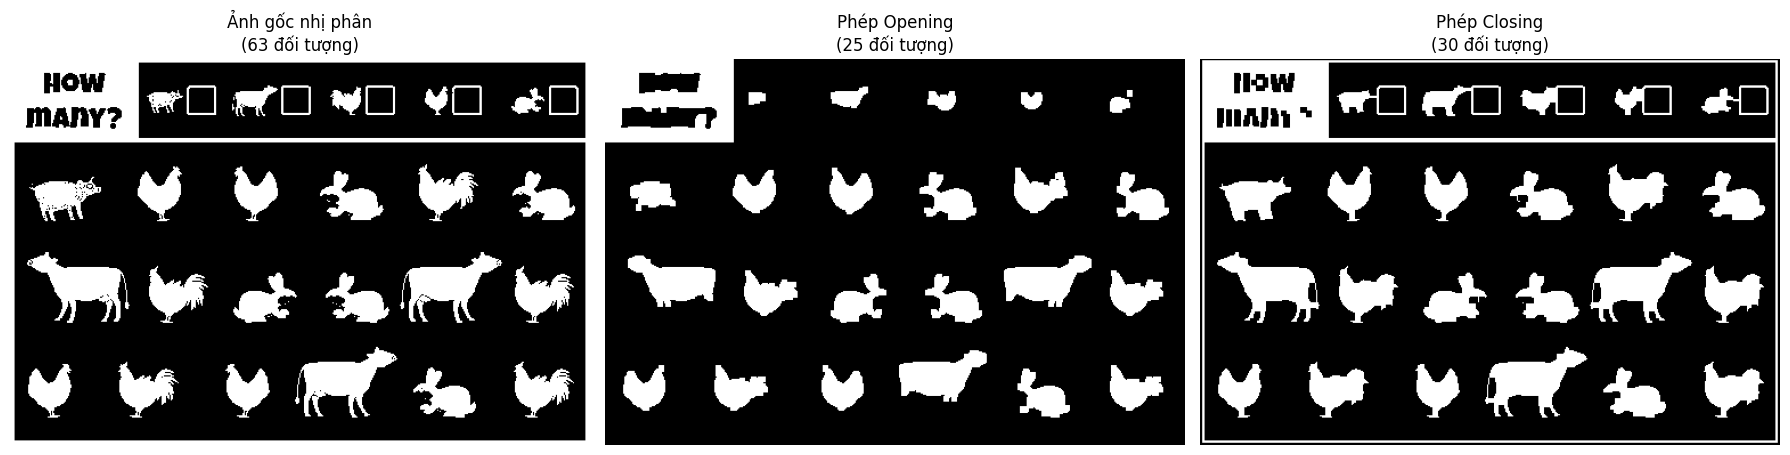

Nhận xét:
 - Opening giúp loại bỏ các đốm nhiễu nhỏ ngoài vùng đối tượng chính.
 - Closing giúp lấp đầy các lỗ trống nhỏ bên trong đối tượng và liên kết các phần đứt quãng.


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# Áp dụng phép Closing với cùng cấu trúc structure_element
closed_image = ndimage.binary_closing(binary_image, structure=structure_element)

# Đếm số đối tượng sau khi Closing
objects_closed = ndimage.label(closed_image)[1]

# Hiển thị và so sánh trực quan
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(binary_image, cmap='gray')
axs[0].set_title(f"Ảnh gốc nhị phân\n({ndimage.label(binary_image)[1]} đối tượng)")
axs[0].axis('off')

axs[1].imshow(opened_image, cmap='gray')
axs[1].set_title(f"Phép Opening\n({objects_after} đối tượng)")
axs[1].axis('off')

axs[2].imshow(closed_image, cmap='gray')
axs[2].set_title(f"Phép Closing\n({objects_closed} đối tượng)")
axs[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Nhận xét:")
print(f" - Opening giúp loại bỏ các đốm nhiễu nhỏ ngoài vùng đối tượng chính.")
print(f" - Closing giúp lấp đầy các lỗ trống nhỏ bên trong đối tượng và liên kết các phần đứt quãng.")

### Bài tập 2: Phân tích chi tiết đối tượng (Tìm trọng tâm - Center of Mass)

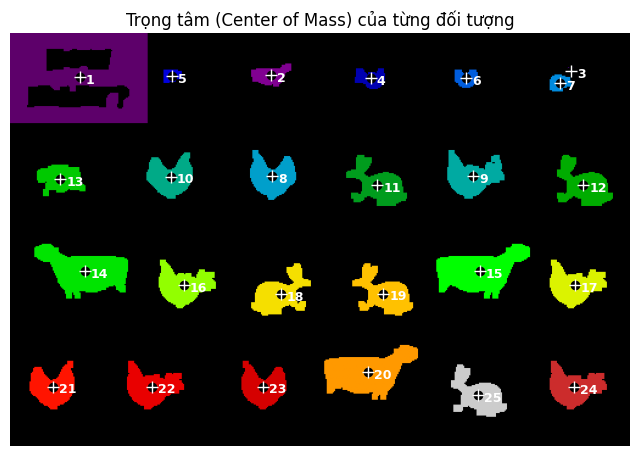

In [14]:
# Tính toán tọa độ trọng tâm (center of mass) cho từng đối tượng đã đánh nhãn
centers = ndimage.center_of_mass(opened_image, labels=labeled_image, index=range(1, num_features + 1))

# Hiển thị ảnh và đánh dấu tọa độ trọng tâm
plt.figure(figsize=(8, 8))
plt.imshow(labeled_image, cmap='nipy_spectral')

# Vẽ các điểm trọng tâm lên ảnh
for i, (cy, cx) in enumerate(centers):
    plt.plot(cx, cy, 'ko', markersize=6)     # Vẽ dấu tròn đen
    plt.plot(cx, cy, 'w+', markersize=8)     # Vẽ dấu cộng trắng ở giữa
    plt.text(cx + 5, cy + 5, f"{i+1}", color='white', fontsize=9, weight='bold')

plt.title("Trọng tâm (Center of Mass) của từng đối tượng")
plt.axis('off')
plt.show()

### Bài tập 3: Lọc đối tượng theo kích thước (> 100 pixels)

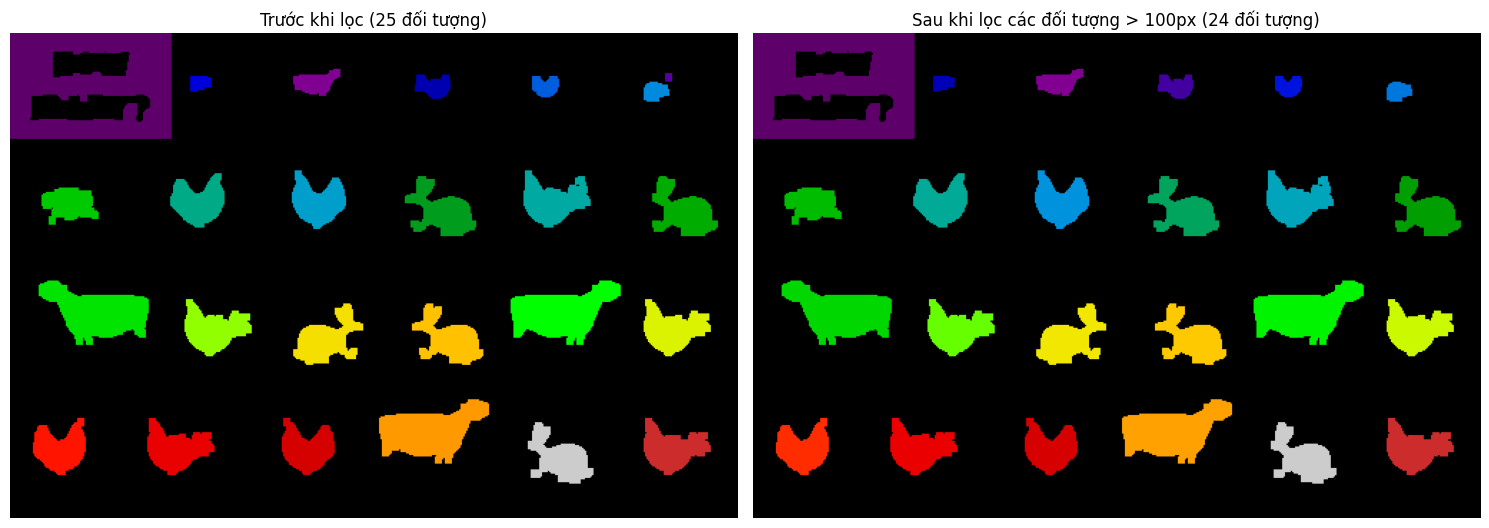

Số lượng đối tượng nhỏ (<= 100px) đã bị lọc bỏ: 1


In [15]:
# Khởi tạo ảnh trống có cùng kích thước để chứa kết quả đã lọc
filtered_image = np.zeros_like(labeled_image)

# Duyệt qua các nhãn và chỉ giữ lại những đối tượng có số pixel > 100
count_filtered = 0
for i in range(1, num_features + 1):
    size = np.sum(labeled_image == i)
    if size > 100:
        count_filtered += 1
        # Gán lại nhãn tuần tự mới cho các đối tượng đạt yêu cầu
        filtered_image[labeled_image == i] = count_filtered

# Vẽ đồ thị so sánh
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

axs[0].imshow(labeled_image, cmap='nipy_spectral')
axs[0].set_title(f"Trước khi lọc ({num_features} đối tượng)")
axs[0].axis('off')

axs[1].imshow(filtered_image, cmap='nipy_spectral')
axs[1].set_title(f"Sau khi lọc các đối tượng > 100px ({count_filtered} đối tượng)")
axs[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Số lượng đối tượng nhỏ (<= 100px) đã bị lọc bỏ: {num_features - count_filtered}")